In [37]:
import torch
import torch.nn as nn # 신경망 구성요소(레이어, 모듈, 손실)
import torch.optim as optim #옵티마이저 함수(가중치 업데이트 알고리즘)
from torch.utils.data import DataLoader, TensorDataset # 데이터셋 추상화와 배치/셔플 처리를 위한 도구

In [38]:
xData = torch.FloatTensor([[1], [2], [3]]) # 입력 데이터
yData = torch.FloatTensor([[10], [20], [30]]) # 정답 데이터 (y=10x)

W = torch.zeros(1, requires_grad=True) # 가중치 초기화 0, requires_grad=True : 파이토치가 자동 미분을 추적하도록 설정
b = torch.zeros(1, requires_grad=True) # 바이어스 초기화 0

o = optim.SGD([W, b], lr=0.01) # SGD써서 W랑 b찾아라, learning_rate=0.01로
# o = optim.Adam([W, b], lr=0.01) # Adam써서 W랑 b찾아라, learning_rate=0.01로


# 에포크(Epoch) : 훈련 데이터 전체를 한 번 모두 사용해서 학습을 완료하는 주기
epochhh = 2200
for i in range(epochhh):
    sik = xData * W + b # 순전파(예측값 계산)
    l = torch.mean((sik - yData) ** 2) # MSE 손실함수

    o.zero_grad() # 기울기 초기화(누적되는 것을 제거) - 1. 기존 기울기 초기화
    l.backward() # 역전파(chainRule) - 2. 현재 기울기 계산
    o.step() # 다음단계로(옵티마이저가 가중치, 바이어스 업데이트) - 3. 업데이트

    print(f"[Epoch {i+1}] W:{W.item():.4f}, b: {b.item():.4f}, loss:{l.item():.4f}")

new_x=torch.FloatTensor([[4]]) # 새로운 입력
pred_y=new_x*W+b # 모델이 예측한 값
print(f"x = {new_x.item()} -> 예측 y = {pred_y.item():.4f}")

[Epoch 1] W:0.9333, b: 0.4000, loss:466.6667
[Epoch 2] W:1.7636, b: 0.7547, loss:369.2740
[Epoch 3] W:2.5021, b: 1.0690, loss:292.2885
[Epoch 4] W:3.1591, b: 1.3476, loss:231.4337
[Epoch 5] W:3.7437, b: 1.5942, loss:183.3292
[Epoch 6] W:4.2639, b: 1.8126, loss:145.3034
[Epoch 7] W:4.7267, b: 2.0058, loss:115.2441
[Epoch 8] W:5.1387, b: 2.1766, loss:91.4820
[Epoch 9] W:5.5053, b: 2.3275, loss:72.6974
[Epoch 10] W:5.8317, b: 2.4608, loss:57.8474
[Epoch 11] W:6.1223, b: 2.5783, loss:46.1073
[Epoch 12] W:6.3811, b: 2.6818, loss:36.8257
[Epoch 13] W:6.6116, b: 2.7730, loss:29.4872
[Epoch 14] W:6.8169, b: 2.8530, loss:23.6847
[Epoch 15] W:6.9999, b: 2.9233, loss:19.0963
[Epoch 16] W:7.1630, b: 2.9848, loss:15.4676
[Epoch 17] W:7.3084, b: 3.0386, loss:12.5975
[Epoch 18] W:7.4381, b: 3.0855, loss:10.3271
[Epoch 19] W:7.5537, b: 3.1263, loss:8.5307
[Epoch 20] W:7.6570, b: 3.1616, loss:7.1090
[Epoch 21] W:7.7492, b: 3.1921, loss:5.9834
[Epoch 22] W:7.8316, b: 3.2183, loss:5.0920
[Epoch 23] W:7.9

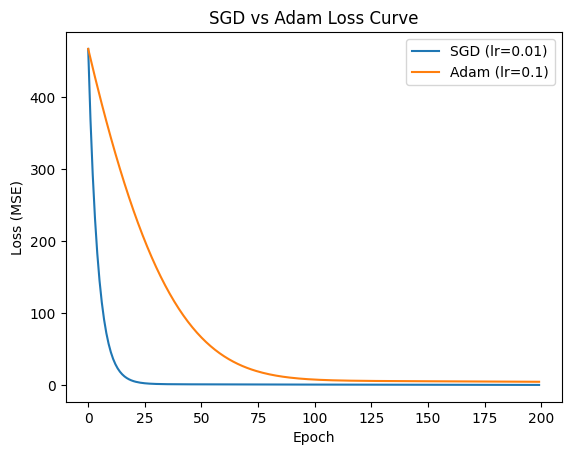

In [39]:
import torch
from torch import optim
import matplotlib.pyplot as plt

# 학습 데이터
xData = torch.FloatTensor([[1], [2], [3]])
yData = torch.FloatTensor([[10], [20], [30]])

# 학습 함수 정의
def train_model(optimizer_type="SGD", lr=0.01, epochs=200):
    # 파라미터 초기화
    W = torch.zeros(1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)

    # 옵티마이저 선택
    if optimizer_type == "SGD":
        optimizer = optim.SGD([W, b], lr=lr)
    elif optimizer_type == "Adam":
        optimizer = optim.Adam([W, b], lr=lr)

    loss_history = []

    for epoch in range(epochs):
        # 예측
        y_pred = xData * W + b
        # 손실 함수 (MSE)
        loss = torch.mean((y_pred - yData) ** 2)

        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 손실 저장
        loss_history.append(loss.item())

    return loss_history

# 두 옵티마이저 학습
epochs = 200
loss_sgd = train_model("SGD", lr=0.01, epochs=epochs)
loss_adam = train_model("Adam", lr=0.1, epochs=epochs)

# 손실 곡선 시각화
plt.plot(loss_sgd, label="SGD (lr=0.01)")
plt.plot(loss_adam, label="Adam (lr=0.1)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("SGD vs Adam Loss Curve")
plt.legend()
plt.show()
